<a href="https://colab.research.google.com/github/Peeyusj/week20_embeddings/blob/main/week20_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install sentence-transformers

In [2]:
from sentence_transformers import SentenceTransformer
model=SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [3]:
sentences = [
    # Medical
    "The doctor treated the patient",
    "The nurse examined the patient",
    "A physician helped the sick person",
    "The surgeon performed the operation",
    "The hospital admitted the patient",
    # Mechanical
    "The mechanic fixed the engine",
    "The car engine was repaired",
    "The engineer serviced the vehicle",
    "The garage fixed the broken car",
    "The technician replaced the parts",
    # Carpentry
    "The carpenter built the table",
    "The woodworker crafted the chair",
    "The craftsman made the cabinet",
    "The joiner assembled the furniture",
    "The builder constructed the shelf",
]
embeddings = model.encode(sentences)
print(embeddings)
print(embeddings.shape)

[[-0.0334436   0.12964526 -0.01536911 ...  0.03683927  0.08941571
   0.05191605]
 [-0.01975979  0.03082473 -0.08931582 ...  0.07430753  0.07273374
  -0.00828646]
 [ 0.01190974  0.1264929  -0.02746686 ...  0.03242916  0.03411444
   0.06186108]
 ...
 [-0.04983364  0.01419413 -0.07745064 ... -0.05151778 -0.00492154
   0.00773633]
 [-0.03474933  0.02256678 -0.01903281 ...  0.0764227  -0.0566556
   0.01454818]
 [-0.05315436  0.10694478 -0.01388748 ... -0.01394535  0.04167872
   0.07565682]]
(15, 384)


In [4]:
from sklearn.metrics.pairwise import cosine_similarity
similarity_matrix = cosine_similarity(embeddings)
print(similarity_matrix.shape)
print(similarity_matrix.round(2))

(15, 15)
[[1.   0.65 0.71 0.59 0.76 0.36 0.35 0.33 0.19 0.24 0.07 0.17 0.08 0.14
  0.07]
 [0.65 1.   0.45 0.41 0.58 0.21 0.2  0.19 0.07 0.17 0.11 0.14 0.01 0.16
  0.05]
 [0.71 0.45 1.   0.37 0.58 0.27 0.23 0.25 0.17 0.19 0.1  0.2  0.13 0.19
  0.11]
 [0.59 0.41 0.37 1.   0.55 0.28 0.34 0.36 0.13 0.24 0.11 0.28 0.11 0.16
  0.11]
 [0.76 0.58 0.58 0.55 1.   0.29 0.31 0.25 0.24 0.19 0.08 0.12 0.05 0.17
  0.13]
 [0.36 0.21 0.27 0.28 0.29 1.   0.77 0.57 0.6  0.55 0.15 0.15 0.26 0.17
  0.17]
 [0.35 0.2  0.23 0.34 0.31 0.77 1.   0.53 0.65 0.53 0.17 0.18 0.29 0.19
  0.23]
 [0.33 0.19 0.25 0.36 0.25 0.57 0.53 1.   0.42 0.5  0.21 0.25 0.3  0.19
  0.22]
 [0.19 0.07 0.17 0.13 0.24 0.6  0.65 0.42 1.   0.46 0.2  0.1  0.25 0.18
  0.24]
 [0.24 0.17 0.19 0.24 0.19 0.55 0.53 0.5  0.46 1.   0.21 0.25 0.36 0.35
  0.28]
 [0.07 0.11 0.1  0.11 0.08 0.15 0.17 0.21 0.2  0.21 1.   0.59 0.53 0.54
  0.59]
 [0.17 0.14 0.2  0.28 0.12 0.15 0.18 0.25 0.1  0.25 0.59 1.   0.53 0.6
  0.46]
 [0.08 0.01 0.13 0.11 0.05 0.26 

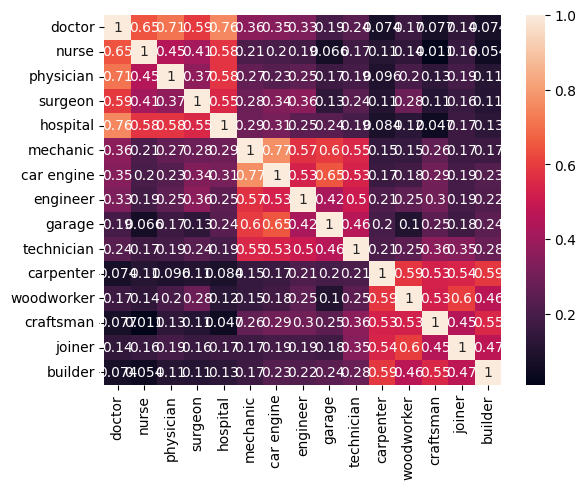

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = [
    "doctor", "nurse", "physician", "surgeon", "hospital",
    "mechanic", "car engine", "engineer", "garage", "technician",
    "carpenter", "woodworker", "craftsman", "joiner", "builder"
]
sns.heatmap(similarity_matrix, annot= True, xticklabels=labels, yticklabels=labels)
plt.show()

In [6]:
embeddings = model.encode(sentences)
print(embeddings.shape)

(15, 384)


In [7]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=5)
embeddings_2d = tsne.fit_transform(embeddings)

print(embeddings_2d.shape)

(15, 2)


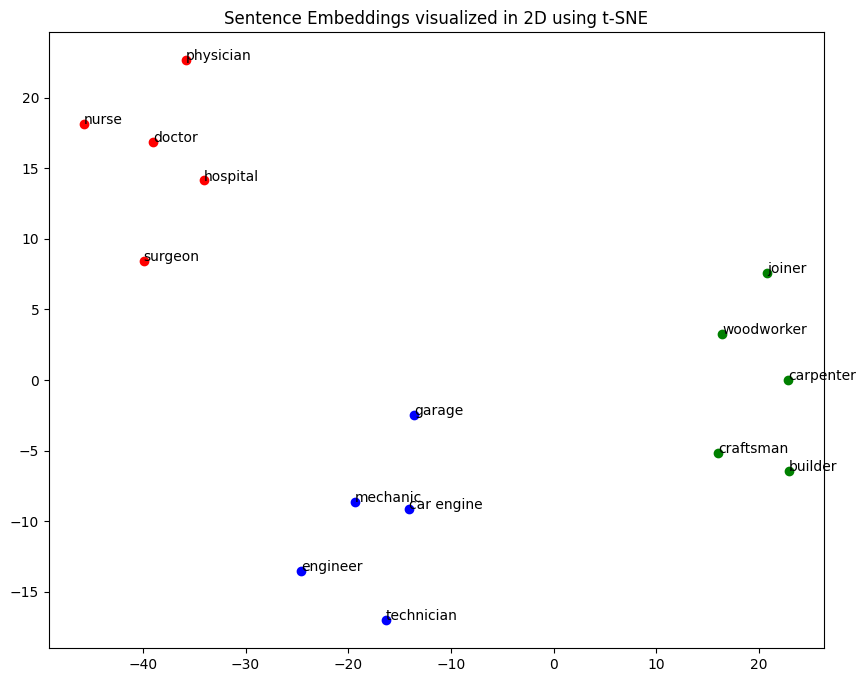

In [11]:
colors = ['red']*5 + ['blue']*5 + ['green']*5
# red   = first 5 sentences  (medical)
# blue  = next 5 sentences   (mechanical)
# green = last 5 sentences   (carpentry)

plt.figure(figsize=(10, 8))

for i in range(15):
    plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], color=colors[i])
    plt.annotate(labels[i], (embeddings_2d[i, 0], embeddings_2d[i, 1]))

plt.title("Sentence Embeddings visualized in 2D using t-SNE")
plt.show()

In [2]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 34.3 MB/s eta 0:00:00


In [4]:
model_w2v = api.load("glove-wiki-gigaword-100")
print("loaded!")

[==================================================] 100.0% 128.1/128.1MB downloaded
loaded!


In [5]:
result = model_w2v.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)
print(result)

[('queen', 0.7698540687561035), ('monarch', 0.6843381524085999), ('throne', 0.6755736470222473), ('daughter', 0.6594556570053101), ('princess', 0.6520534157752991)]
